In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import pandas as pd

In [2]:
# Evolution of CO2 concentration in the atmosphere between January and April before, during and after COVID-19
# Explore difference between CO2 profiles before and during COVID
array_sr_pre_jan = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20160115_B10206Ar.npy')
array_sr_pre_apr = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20160415_B10206Ar.npy')
array_sr_covid_apr = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20160815_B10206Ar.npy')
array_sr_covid_jan = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20161215_B10206Ar.npy')
# array_sr_post_april = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20210424_B10206Ar.npy')
# array_sr_post_jan = np.load('../RDS/ephemeral/OCO-2/oco2_GEOS_L3CO2_day_20210124_B10206Ar.npy')

array_sr_pre_jan *= 1e6
array_sr_pre_apr *= 1e6
array_sr_covid_apr *= 1e6
array_sr_covid_jan *= 1e6
# array_sr_post_april *= 1e6
# array_sr_post_jan *= 1e6

extent = [-180, 180, -90, 90]

# Rearange coordinates as latitude and longitude
# x_ticks = np.linspace(0, array_sr_pre.shape[1], num=9)
# x_coord = np.linspace(-180, 180, num=9)
# y_ticks = np.linspace(0, array_sr_pre.shape[0], num=9)
# y_coord = np.linspace(-90, 90, num=9)
# Same colormap for both plots
vmax = max(np.max(array_sr_pre_jan), np.max(array_sr_covid_jan),\
           np.max(array_sr_pre_apr), np.max(array_sr_covid_apr))
vmin = min(np.min(array_sr_pre_jan), np.min(array_sr_covid_jan),\
              np.min(array_sr_pre_apr), np.min(array_sr_covid_apr))

In [ ]:
# Plot on subplots
fig, axs = plt.subplots(2, 2, figsize=(20, 15), subplot_kw={'projection': ccrs.PlateCarree()})
axs[0,0].imshow(array_sr_pre_jan, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
axs[0,1].imshow(array_sr_pre_apr, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
axs[1,0].imshow(array_sr_covid_jan, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
im = axs[1,1].imshow(array_sr_covid_apr, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
# axs[2,0].imshow(array_sr_post_jan, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
# im = axs[2,1].imshow(array_sr_post_april, aspect='auto', origin="lower", extent=extent, cmap='viridis', vmax=vmax, vmin=vmin)
# axs[0,0].invert_yaxis()
# axs[0,1].invert_yaxis()
# axs[1,0].invert_yaxis()
# Coords
# axs[0,0].set_xticks(x_ticks)
# axs[0,0].set_xticklabels(x_coord)
# axs[0,0].set_yticks(y_ticks)
# axs[0,0].set_yticklabels(y_coord)

# axs[0,1].set_xticks(x_ticks)
# axs[0,1].set_xticklabels(x_coord)
# axs[0,1].set_yticks(y_ticks)
# axs[0,1].set_yticklabels(y_coord)

# axs[1,0].set_xticks(x_ticks)
# axs[1,0].set_xticklabels(x_coord)
# axs[1,0].set_yticks(y_ticks)
# axs[1,0].set_yticklabels(y_coord)

axs[0,0].coastlines(resolution='50m')
axs[0,1].coastlines(resolution='50m')
axs[1,0].coastlines(resolution='50m')
axs[1,1].coastlines(resolution='50m')
# axs[2,0].coastlines(resolution='50m')
# axs[2,1].coastlines(resolution='50m')

# axs[0,0].set_title('CO2 Distribution Pre-COVID (24 Jan 2019)', fontsize=18)
# axs[0,1].set_title('CO2 Distribution Pre-COVID (24 Apr 2019)', fontsize=18)
# axs[1,0].set_title('CO2 Distribution COVID (24 Jan 2020)', fontsize=18)
# axs[1,1].set_title('CO2 Distribution COVID (24 Apr 2020)', fontsize=18)
# axs[2,0].set_title('CO2 Distribution Post-COVID (24 Jan 2021)', fontsize=18)
# axs[2,1].set_title('CO2 Distribution Post-COVID (24 Apr 2021)', fontsize=18)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)
cbar_ax.set_ylabel('XCO2 (ppm)', fontsize=18)
# plt.tight_layout()
plt.show()


IndexError: index 2 is out of bounds for axis 0 with size 2

On this figure we see the evolution of CO2 concentration over the COVID period. Even considering the seasonal increase in CO2 concentration, we can see that usual spots of high CO2 emissions have lowered their activity, triggering a comparatively low increase in CO2 concentration.

In [18]:
def find_indices(array, value):
    indices = np.argmin(np.abs(array - value))
    return indices

lons = np.linspace(-180, 180, num=array_sr_pre.shape[1])
lons[find_indices(lons, -78.)]

-77.99674443841563

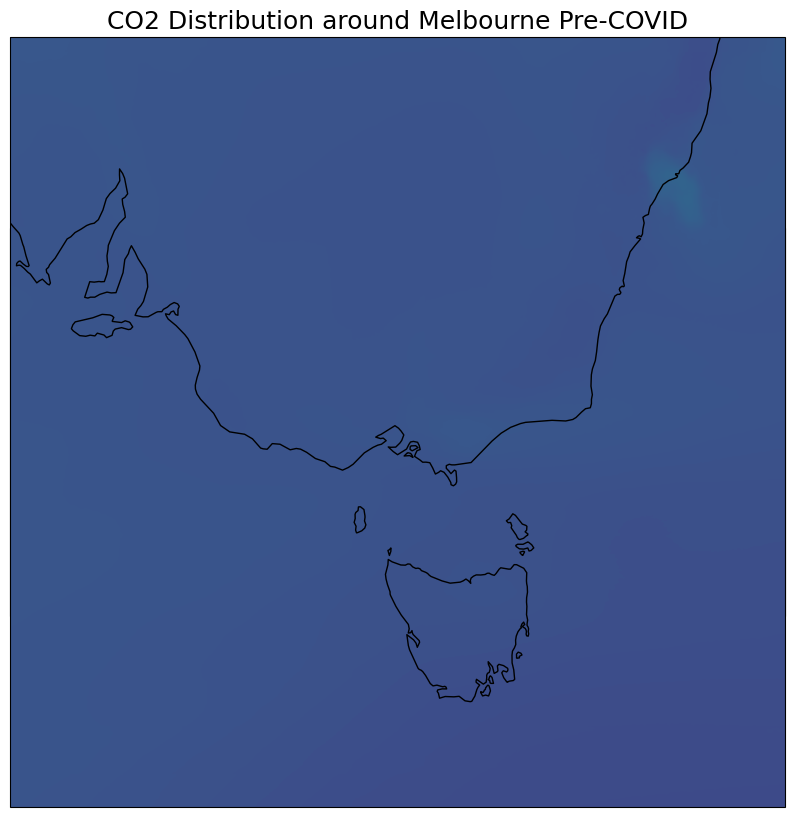

In [29]:
# Areas to consider: Melbourne, Beijing, Bogota, Paris, Lusaka
# Melbourne: -37.8136, 144.9631
# Beijing: 39.9042, 116.4074
# Bogota: 4.710989, -74.072092
# Paris: 48.8566, 2.3522
# Lusaka: -15.3875, 28.3228

lons = np.linspace(-180, 180, num=array_sr_pre.shape[1])
lats = np.linspace(-90, 90, num=array_sr_pre.shape[0])
area_size = 256

# Plot area around city
# Melbourne
melbourne_lon = 144.9631
melbourne_lat = -37.8136
melbourne_lon_idx = find_indices(lons, melbourne_lon)
melbourne_lat_idx = find_indices(lats, melbourne_lat)
extent = [lons[melbourne_lon_idx-area_size], lons[melbourne_lon_idx+area_size],\
          lats[melbourne_lat_idx-area_size], lats[melbourne_lat_idx+area_size]]
# Boxes pre-covid, during covid and post-covid
box_melbourne_pre = array_sr_pre[melbourne_lat_idx-area_size:melbourne_lat_idx+area_size,\
                                 melbourne_lon_idx-area_size:melbourne_lon_idx+area_size]
box_melbourne_covid = array_sr_covid[melbourne_lat_idx-area_size:melbourne_lat_idx+area_size,\
                                melbourne_lon_idx-area_size:melbourne_lon_idx+area_size]
box_melbourne_post = array_sr_post[melbourne_lat_idx-area_size:melbourne_lat_idx+area_size,\
                                melbourne_lon_idx-area_size:melbourne_lon_idx+area_size]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax=plt.subplot(111, projection=ccrs.PlateCarree())
ax.imshow(box_melbourne_post, aspect='auto', extent=extent, origin="lower", cmap='viridis',\
           vmax=vmax, vmin=vmin, transform=ccrs.PlateCarree())
ax.coastlines(resolution='50m')
plt.title('CO2 Distribution around Melbourne Pre-COVID', fontsize=18)
# plt.colorbar(im, ax=plt.gca(), orientation='vertical', fraction=0.046, pad=0.04).set_label('XCO2 (ppm)', fontsize=18)
plt.show()
